## Setup

In [2]:
# Colab setup
import os

if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess
    subprocess.run('wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh', shell=True)
    cmd = subprocess.run('bash colab_setup.sh TUTORIAL', shell=True, stdout=subprocess.PIPE)
    print(cmd.stdout.decode('utf-8'))

# IMPORT PACKAGES
import torch
import lightning
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(42)

In [3]:
from mlcolvar.data import DictModule, DictDataset
from mlcolvar.utils.fes import compute_fes, compute_deltaG

def convert_model(model_name, n_input):
    loaded_model = torch.jit.load(model_name).to(torch.device('cpu')).to(torch.float32)
    fake_input = torch.rand((1,n_input)).to(torch.float32)
    loaded_model(fake_input)
    frozen_model = torch.jit.trace(loaded_model, fake_input)
    torch.jit.save(frozen_model, model_name)


/home/grossi1-iit.local/miniforge3/envs/mlcolvar_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Initialize common objects for all iterations

In [4]:
# temperature in Kelvin
T = 310 
kb = 0.0083144621 # kJ/mol
beta = 1/(kb*T)
kbt=kb*T

print(f'Beta: {beta} \n1/beta: {1/beta}')

Beta: 0.38797536302593805 
1/beta: 2.577483251


# Iteration 0

### Load data

In [6]:
from mlcolvar.utils.io import create_dataset_from_files
from mlcolvar.cvs.committor.utils import compute_committor_weights
from mlcolvar.data import DictModule

filenames = [
            "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/unbiased/no_stalk/COLVAR",
            "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/unbiased/stalk/COLVAR",
]

load_args = [
            {'start' : 0, 'stop': 10000, 'stride': 2},
             {'start' : 0, 'stop': 10000, 'stride': 2}
            ]        

# load data
dataset, dataframe = create_dataset_from_files(file_names = filenames,
                                               create_labels = True,
                                               filter_args={'regex' : r'^c_[0-9]'},
                                               return_dataframe = True,
                                               load_args=load_args,
                                               verbose = True)

# get bias 
bias = torch.zeros(len(dataset))

# compute weights
dataset = compute_committor_weights(dataset=dataset, 
                                    bias=bias, 
                                    data_groups=[0, 1], 
                                    beta=beta)

# initialize datamodule
datamodule = DictModule(dataset, lengths=[1])

Class 0 dataframe shape:  (5000, 57)
Class 1 dataframe shape:  (5000, 57)

 - Loaded dataframe (10000, 57): ['time', 'memFusion', 'c_mus4', 'c_tails.0', 'c_tails.1', 'c_tails.2', 'c_tails.3', 'c_tails.4', 'c_tails.5', 'c_tails.6', 'c_tails.7', 'c_tails.8', 'c_tails.9', 'c_tails.10', 'c_tails.11', 'c_tails.12', 'c_tails.13', 'c_tails.14', 'c_tails.15', 'c_tails.16', 'c_tails.17', 'c_0', 'c_1', 'c_2', 'c_3', 'c_4', 'c_5', 'c_6', 'c_7', 'c_8', 'c_9', 'c_10', 'c_11', 'c_12', 'c_13', 'c_14', 'c_15', 'c_16', 's_0', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 'walker', 'labels']
 - Descriptors (10000, 17): ['c_0', 'c_1', 'c_2', 'c_3', 'c_4', 'c_5', 'c_6', 'c_7', 'c_8', 'c_9', 'c_10', 'c_11', 'c_12', 'c_13', 'c_14', 'c_15', 'c_16']


### Initialize model

In [10]:
from mlcolvar.cvs.committor import Committor
import copy

# initialize lr scheduler
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR

# create options dictionary
options = {'optimizer' : {'lr': 1e-3, 'weight_decay': 1e-5}, 
           'lr_scheduler' : { 'scheduler' : lr_scheduler, 'gamma' : 0.9999 },
            'nn' : {'activation' : 'tanh'}}

# initialize model
model = Committor(model=[17, 14, 12, 1],
                  atomic_masses=None,
                  alpha=1,
                  options=options, 
                  separate_boundary_dataset=False,
                  descriptors_derivatives=None,
                  norm_in=True,
                  log_var=True,         
                  gamma=1,
                  z_regularization=False,
                  use_gradients_wrt_positions=False,
                  n_dim=1 
                  )

# copy the last layer sigmoid activation function so we can enable/disable it
Sigmoid = copy.copy(model.sigmoid)

### Train model

In [11]:
from mlcolvar.utils.trainer import MetricsCallback

# define callbacks
metrics = MetricsCallback()

# initialize trainer
trainer = lightning.Trainer(callbacks=[metrics], 
                            max_epochs=10000, 
                            logger=False, 
                            enable_checkpointing=False, # disabling or softening checkpointing could make it faster
                            limit_val_batches=0,    # this to skip validation
                            num_sanity_val_steps=0  # this to skip validation
                            )

# fit model
trainer.fit(model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA RTX A4000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type           | Params | Mode  | In sizes | Out sizes
--------------------------------------------------------------------------
0 | loss_fn | CommittorLoss  | 0      | train | ?        | ?        
1 | norm_in | Normalization  | 0      | train | [1, 17]  | [1, 17]  
2 | nn      | FeedForward    | 445    | train | [1, 17]  | [1, 1]   
3 | sigmoid | Custom_Sigmoid | 0      | train | [1, 1]   | [1, 1]   
--------------------------------------------------------------------------
445       Trainable param

Epoch 9999: 100%|██████████| 1/1 [00:00<00:00, 117.46it/s]

`Trainer.fit` stopped: `max_epochs=10000` reached.


Epoch 9999: 100%|██████████| 1/1 [00:00<00:00, 104.84it/s]


### Check training metrics

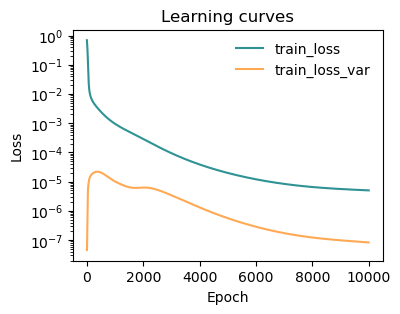

In [12]:
from mlcolvar.utils.plot import plot_metrics

# plot metrics
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax = plot_metrics(metrics.metrics,
                  keys=['train_loss', 'train_loss_var'],
                  colors=['fessa1', 'fessa5'],
                  yscale='log',
                  ax = ax)

### Visualize training results

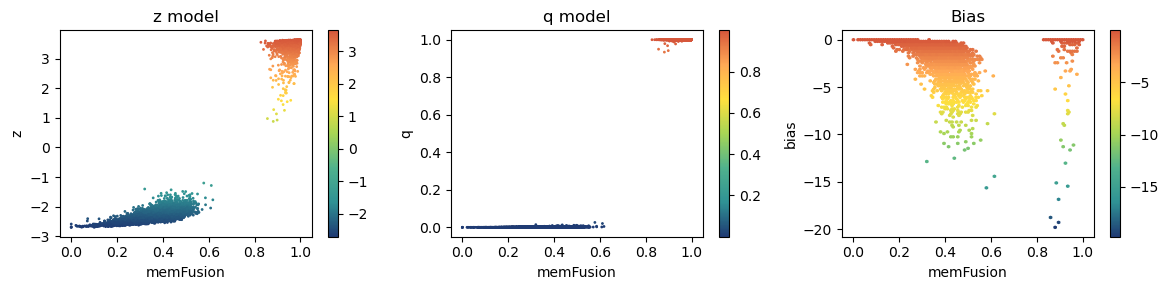

In [13]:
from mlcolvar.cvs.committor.utils import KolmogorovBias

fig, axs = plt.subplots(1,3,figsize=(12,3))

# plot z --> activation off, directly distances as inputs
model.sigmoid = None

ax = axs[0]
ax.set_xlabel('memFusion')
ax.set_ylabel('z')
ax.set_title('z model')
aux = model(dataset['data'])
cp = ax.scatter(dataframe['memFusion'], aux.cpu().detach().numpy(), c=aux.cpu().detach().numpy(), s=1, cmap='fessa')
plt.colorbar(cp, ax=ax)

# plot q --> activation on, directly distances as inputs
model.sigmoid = Sigmoid

ax = axs[1]
ax.set_xlabel('memFusion')
ax.set_ylabel('q')
ax.set_title('q model')
aux = model(dataset['data'])
cp = ax.scatter(dataframe['memFusion'], aux.cpu().detach().numpy(),c=aux.cpu().detach().numpy(), s=1, cmap='fessa')
plt.colorbar(cp, ax=ax)

# plot Kolmogorov bias --> activation on, distances as inputs as we do in PLUMED
model.sigmoid = Sigmoid

ax = axs[2]
ax.set_xlabel('memFusion')
ax.set_ylabel('bias')
ax.set_title('Bias')
bias_model = KolmogorovBias(model, lambd=2, beta=1)
aux = bias_model((dataset['data']))
cp = ax.hexbin(dataframe['memFusion'], aux.cpu().detach().numpy(), C=aux.cpu().detach().numpy(), cmap='fessa')
plt.colorbar(cp, ax=ax)

plt.tight_layout()
plt.show()

### Export trained model to torchscript

In [ ]:
iter = 0

# export z model --> activation off
model.sigmoid = None
model.to_torchscript(f'model_{iter}_z.pt', method='trace')
convert_model(f'model_{iter}_z.pt', 17)

# export q model --> activation on
model.sigmoid = Sigmoid
model.to_torchscript(f'model_{iter}_q.pt', method='trace')
convert_model(f'model_{iter}_q.pt', 17)

### Run plumed simulations
Here it is convient to create a submission script that updates the input file depending on the iteration you ar at and launches the simulations.

One good approach is to have a template simulation folder with all the inputs and then call the models, simulations folder etc. with progressive names based on the iterations. 
This way it is easy to write a script that depending on the iteration yuo are it changes the few parts that need to be changed in the input files.

For example:


`RUN_SIMULATION = f"cd biased_sims && bash generate_and_run_sims.sh {iter}"`

`subprocess.run(f"{RUN_SIMULATION}", shell=True, executable='/bin/bash')`

### Visualize sampling

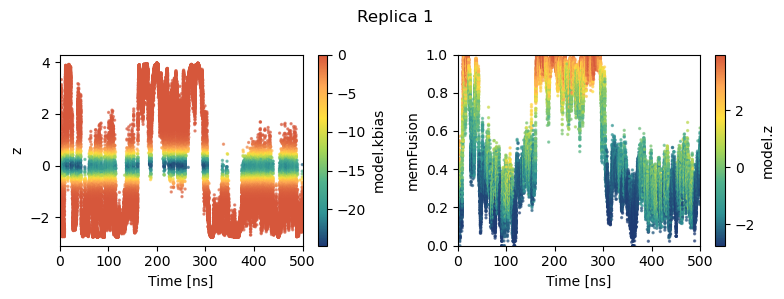

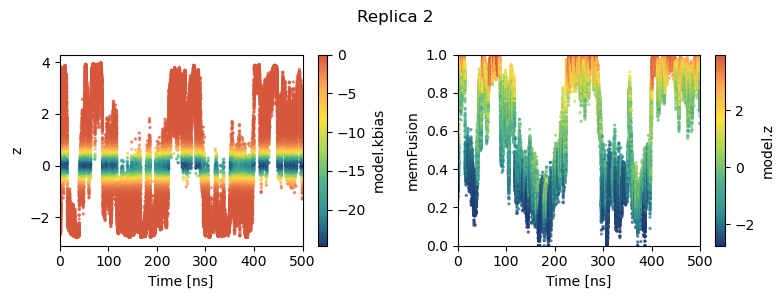

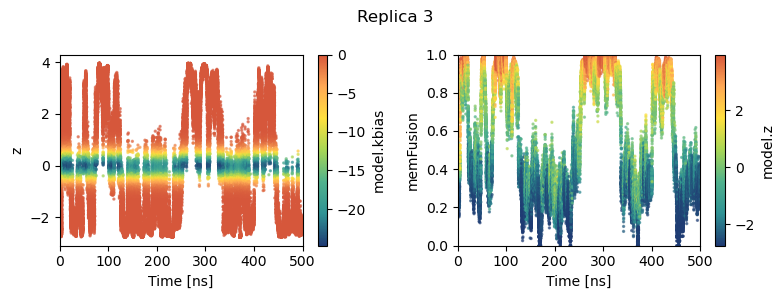

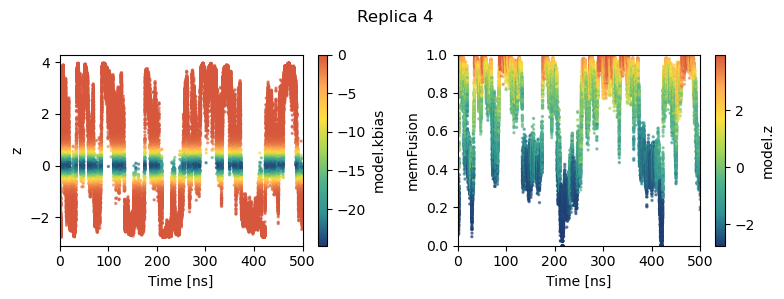

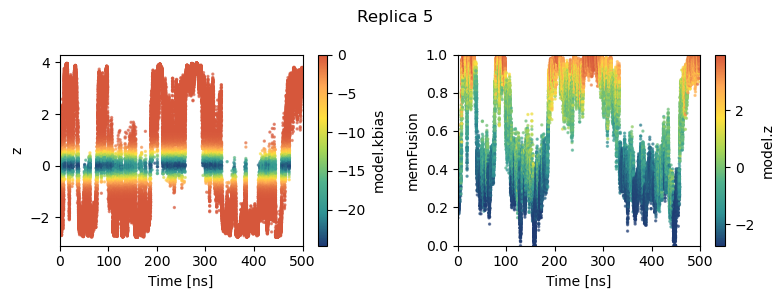

In [9]:
from mlcolvar.utils.io import load_dataframe


for rep in range(1,6):
    sampling = load_dataframe([f"https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/biased/iter_0/COLVAR_{rep}"]) 
                                                    
    fig, axs = plt.subplots(1,2,figsize=((8,3)))

    plt.suptitle(f'Replica {rep}')

    ax = axs[0]

    ax.set_xlabel('Time [ns]')
    ax.set_ylabel('z')
    ax.set_xlim(0,500)

    cp = ax.scatter(sampling['time']/1000, sampling['model.z'], c=sampling['model.kbias'], cmap='fessa',s=2, alpha=0.6)
    cb = plt.colorbar(cp, ax=ax, label='model.kbias')
    cb.solids.set(alpha=1)

    ax = axs[1]

    ax.set_xlabel('Time [ns]')
    ax.set_ylabel('memFusion')

    cp = ax.scatter(sampling['time']/1000, sampling['memFusion'], c=sampling['model.z'], cmap='fessa',s=2, alpha=0.6)
    cb = plt.colorbar(cp, ax=ax, label='model.z')
    cb.solids.set(alpha=1)
    ax.set_ylim(0, 1)
    ax.set_xlim(0,500)

    plt.tight_layout()
    plt.show()

# Iteration 1

### Load data

In [18]:
filenames = [
             "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/unbiased/no_stalk/COLVAR", 
             "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/unbiased/stalk/COLVAR",
             "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/biased/iter_0/COLVAR_1",
             "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/biased/iter_0/COLVAR_2",
             "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/biased/iter_0/COLVAR_3",
             "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/biased/iter_0/COLVAR_4",
             "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/biased/iter_0/COLVAR_5"
              ]

load_args = [
             {'start' : 0, 'stop': 10000, 'stride': 2},
             {'start' : 0, 'stop': 10000, 'stride': 2},
             {'start' : 1000, 'stop': 50000, 'stride': 5},
             {'start' : 1000, 'stop': 50000, 'stride': 5},
             {'start' : 1000, 'stop': 50000, 'stride': 5},
             {'start' : 1000, 'stop': 50000, 'stride': 5},
             {'start' : 1000, 'stop': 50000, 'stride': 5},
            ]        

# load data
dataset, dataframe = create_dataset_from_files(file_names = filenames,
                                               create_labels = True,
                                               filter_args={'regex' : r'^c_[0-9]'},
                                               return_dataframe = True,
                                               load_args=load_args,
                                               verbose = True)

# get bias
dataframe = dataframe.fillna({'opes.bias': 0, 'model.kbias' : 0})
bias = torch.Tensor(dataframe['opes.bias'].values + dataframe['model.kbias'].values) 

# compute weights
dataset = compute_committor_weights(dataset=dataset, 
                                    bias=bias, 
                                    data_groups=[0, 1, 2, 3, 4, 5, 6],
                                    beta=beta)

# initialize datamodule
datamodule = DictModule(dataset, lengths=[1])

Class 0 dataframe shape:  (5000, 57)
Class 1 dataframe shape:  (5000, 57)
Class 2 dataframe shape:  (9800, 52)
Class 3 dataframe shape:  (9800, 52)
Class 4 dataframe shape:  (9800, 52)
Class 5 dataframe shape:  (9800, 52)
Class 6 dataframe shape:  (9800, 52)

 - Loaded dataframe (59000, 69): ['time', 'memFusion', 'c_mus4', 'c_tails.0', 'c_tails.1', 'c_tails.2', 'c_tails.3', 'c_tails.4', 'c_tails.5', 'c_tails.6', 'c_tails.7', 'c_tails.8', 'c_tails.9', 'c_tails.10', 'c_tails.11', 'c_tails.12', 'c_tails.13', 'c_tails.14', 'c_tails.15', 'c_tails.16', 'c_tails.17', 'c_0', 'c_1', 'c_2', 'c_3', 'c_4', 'c_5', 'c_6', 'c_7', 'c_8', 'c_9', 'c_10', 'c_11', 'c_12', 'c_13', 'c_14', 'c_15', 'c_16', 's_0', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 'walker', 'labels', 'lwall.bias', 'lwall.force2', 'model.z', 'model.q', 'model.kbias', 'potential.bias', 'potential.model.kbias_bias', 'opes.bias', 'opes.rct', 'opes.zed', 'opes.nef

### Initialize model

In [19]:
# initialize lr scheduler
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR

# create options dictionary
options = {'optimizer' : {'lr': 1e-3, 'weight_decay': 1e-5}, 
           'lr_scheduler' : { 'scheduler' : lr_scheduler, 'gamma' : 0.9999 },
            'nn' : {'activation' : 'tanh'}}

# initialize model
model = Committor(model=[17, 14, 12, 1],
                         atomic_masses=None,
                         alpha=1e-3,
                         options=options, 
                         separate_boundary_dataset=True,
                         descriptors_derivatives=None,
                         norm_in=True,
                         log_var=True,        
                         gamma=1e3,
                         z_regularization=False,
                         use_gradients_wrt_positions=False,
                         n_dim=1     ) 

# copy the last layer sigmoid activation function so we can enable/disable it
Sigmoid = copy.copy(model.sigmoid)

### Train model

In [20]:
# define callbacks
metrics = MetricsCallback()

# initialize trainer
trainer = lightning.Trainer(callbacks=[metrics], 
                            max_epochs=5000, 
                            logger=False, 
                            enable_checkpointing=False, # disabling or softening checkpointing could make it faster
                            limit_val_batches=0,    # this to skip validation
                            num_sanity_val_steps=0  # this to skip validation
                            )

# fit model
trainer.fit(model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type           | Params | Mode  | In sizes | Out sizes
--------------------------------------------------------------------------
0 | loss_fn | CommittorLoss  | 0      | train | ?        | ?        
1 | norm_in | Normalization  | 0      | train | [1, 17]  | [1, 17]  
2 | nn      | FeedForward    | 445    | train | [1, 17]  | [1, 1]   
3 | sigmoid | Custom_Sigmoid | 0      | train | [1, 1]   | [1, 1]   
--------------------------------------------------------------------------
445       Trainable params
0         Non-trainable params
445       Total params
0.002     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Epoch 4999: 100%|██████████| 1/1 [00:00<00:00, 112.48it/s]

`Trainer.fit` stopped: `max_epochs=5000` reached.


Epoch 4999: 100%|██████████| 1/1 [00:00<00:00, 100.54it/s]


### Check training metrics

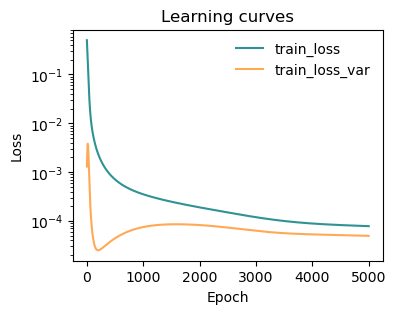

In [21]:
# plot metrics
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax = plot_metrics(metrics.metrics,
                  keys=['train_loss', 'train_loss_var'],
                  colors=['fessa1', 'fessa5'],
                  yscale='log',
                  ax = ax)

### Visualize training results

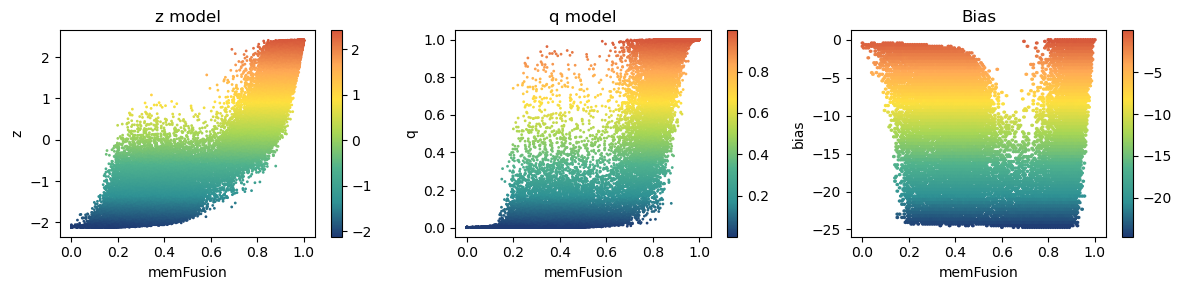

In [22]:
from mlcolvar.cvs.committor.utils import KolmogorovBias

fig, axs = plt.subplots(1,3,figsize=(12,3))

# plot z --> activation off, directly distances as inputs
model.sigmoid = None

ax = axs[0]
ax.set_xlabel('memFusion')
ax.set_ylabel('z')
ax.set_title('z model')
aux = model(dataset['data'])
cp = ax.scatter(dataframe['memFusion'], aux.cpu().detach().numpy(), c=aux.cpu().detach().numpy(), s=1, cmap='fessa')
plt.colorbar(cp, ax=ax)

# plot q --> activation on, directly distances as inputs
model.sigmoid = Sigmoid

ax = axs[1]
ax.set_xlabel('memFusion')
ax.set_ylabel('q')
ax.set_title('q model')
aux = model(dataset['data'])
cp = ax.scatter(dataframe['memFusion'], aux.cpu().detach().numpy(),c=aux.cpu().detach().numpy(), s=1, cmap='fessa')
plt.colorbar(cp, ax=ax)

# plot Kolmogorov bias --> activation on, distances as inputs as we do in PLUMED
model.sigmoid = Sigmoid

ax = axs[2]
ax.set_xlabel('memFusion')
ax.set_ylabel('bias')
ax.set_title('Bias')
bias_model = KolmogorovBias(model, lambd=2, beta=1)
aux = bias_model((dataset['data']))
cp = ax.hexbin(dataframe['memFusion'], aux.cpu().detach().numpy(), C=aux.cpu().detach().numpy(), cmap='fessa')
plt.colorbar(cp, ax=ax)

plt.tight_layout()
plt.show()

### Export trained model to torchscript

In [ ]:
iter = 1

# turn of preprocessing as in PLUMED we precompute the descriptors to make it faster
model.preprocessing = None

# export z model --> activation off
model.sigmoid = None
model.to_torchscript(f'model_{iter}_z.pt', method='trace')
convert_model(f'model_{iter}_z.pt', 17)

# export q model --> activation on
model.sigmoid = Sigmoid
model.to_torchscript(f'model_{iter}_q.pt', method='trace')
convert_model(f'model_{iter}_q.pt', 17)

/home/grossi1-iit.local/miniforge3/envs/mlcolvar_env/lib/python3.10/site-packages/torch/jit/_trace.py:685: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  warnings.warn(


### Compare models

Class 0 dataframe shape:  (7001, 52)
Class 1 dataframe shape:  (7001, 52)
Class 2 dataframe shape:  (7001, 52)
Class 3 dataframe shape:  (7001, 52)
Class 4 dataframe shape:  (7001, 52)

 - Loaded dataframe (35005, 52): ['time', 'memFusion', 'c_mus4', 'c_tails.0', 'c_tails.1', 'c_tails.2', 'c_tails.3', 'c_tails.4', 'c_tails.5', 'c_tails.6', 'c_tails.7', 'c_tails.8', 'c_tails.9', 'c_tails.10', 'c_tails.11', 'c_tails.12', 'c_tails.13', 'c_tails.14', 'c_tails.15', 'c_tails.16', 'c_tails.17', 'c_0', 'c_1', 'c_2', 'c_3', 'c_4', 'c_5', 'c_6', 'c_7', 'c_8', 'c_9', 'c_10', 'c_11', 'c_12', 'c_13', 'c_14', 'c_15', 'c_16', 'lwall.bias', 'lwall.force2', 'model.z', 'model.q', 'model.kbias', 'potential.bias', 'potential.model.kbias_bias', 'opes.bias', 'opes.rct', 'opes.zed', 'opes.neff', 'opes.nker', 'walker', 'labels']
 - Descriptors (35005, 17): ['c_0', 'c_1', 'c_2', 'c_3', 'c_4', 'c_5', 'c_6', 'c_7', 'c_8', 'c_9', 'c_10', 'c_11', 'c_12', 'c_13', 'c_14', 'c_15', 'c_16']


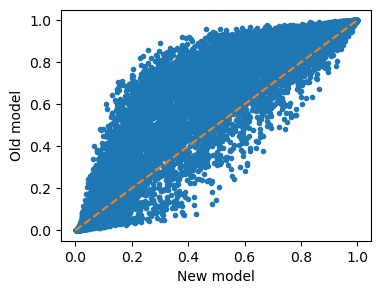

In [7]:
iter = 1

# load models
model_new = torch.jit.load(f"/home/grossi1-iit.local/giorgia/membrane/membrane_fusion_committor/models//model_{iter}_q.pt")#.to(torch.float64)
model_old = torch.jit.load(f"/home/grossi1-iit.local/giorgia/membrane/membrane_fusion_committor/models//model_{iter-1}_q.pt")#.to(torch.float64)

# when training for the first time use the available data you have at that iteration
# using this data now
filenames = [
                "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/biased/iter_1/COLVAR_1",
                "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/biased/iter_1/COLVAR_2",
                "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/biased/iter_1/COLVAR_3",
                "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/biased/iter_1/COLVAR_4",
                "https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/biased/iter_1/COLVAR_5"
              ]

load_args = [
             {'start' : 15000, 'stop': 100000, 'stride': 5},
             {'start' : 15000, 'stop': 100000, 'stride': 5},
             {'start' : 15000, 'stop': 100000, 'stride': 5},
             {'start' : 15000, 'stop': 100000, 'stride': 5},
             {'start' : 15000, 'stop': 100000, 'stride': 5},
            ]        

# #######################################################################################

test_dataset, test_dataframe = create_dataset_from_files(file_names = filenames,
                                               create_labels = True,
                                               filter_args={'regex' : r'^c_[0-9]'},
                                               return_dataframe = True,
                                               load_args=load_args,
                                               verbose = True)

pred_A = model_new(test_dataset['data']).detach()
pred_B = model_old(test_dataset['data']).detach()

# plot results
plt.figure(figsize=(4,3))
plt.plot(pred_A, pred_B, '.')
plt.xlabel('New model')
plt.ylabel('Old model')
# plot reference line
plt.plot( [0,1], [0, 1], ls='dashed')
plt.show()

### Run plumed simulations
Here it is convient to create a submission script that updates the input file depending on the iteration you ar at and launches the simulations.

One good approach is to have a template simulation folder with all the inputs and then call the models, simulations folder etc. with progressive names based on the iterations. 
This way it is easy to write a script that depending on the iteration yuo are it changes the few parts that need to be changed in the input files.

For example:


`RUN_SIMULATION = f"cd biased_sims && bash generate_and_run_sims.sh {iter}"`

`subprocess.run(f"{RUN_SIMULATION}", shell=True, executable='/bin/bash')`

### Visualize sampling

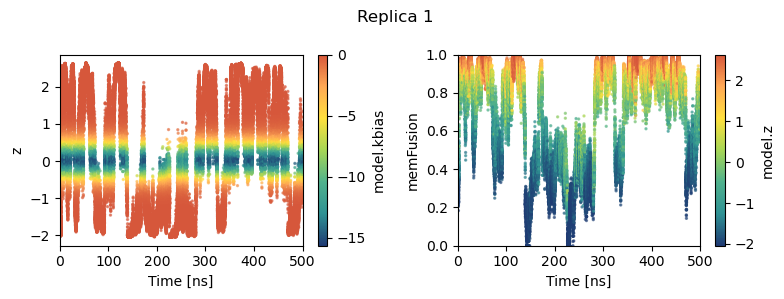

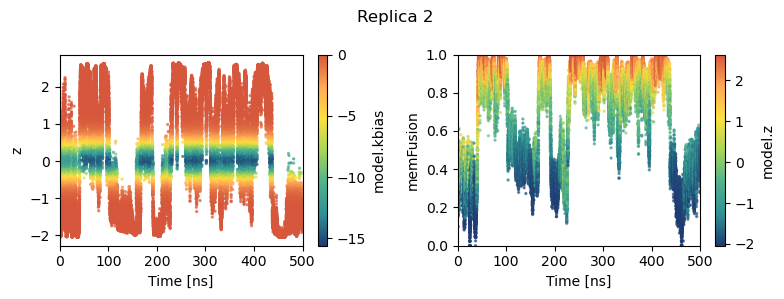

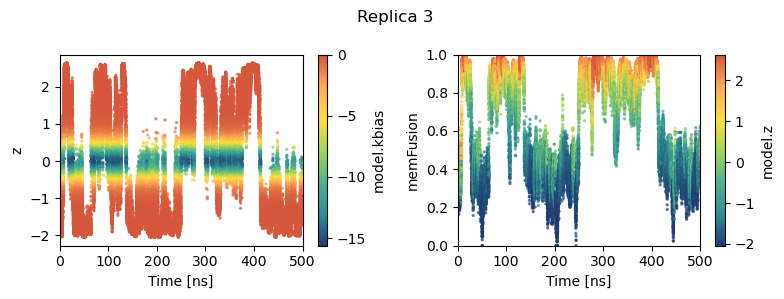

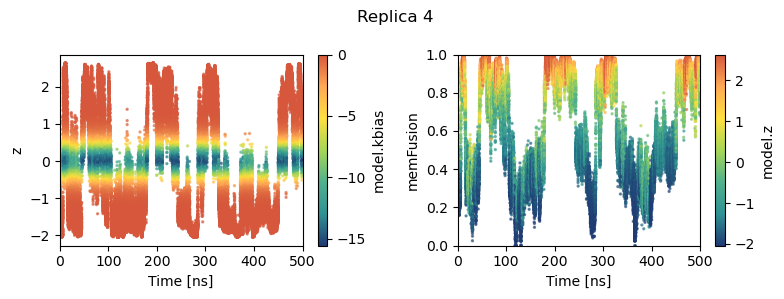

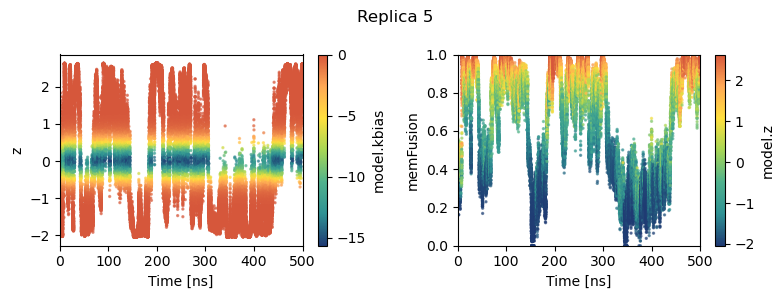

In [10]:
from mlcolvar.utils.io import load_dataframe


for rep in range(1,6):
    sampling = load_dataframe([f"https://github.com/giorgiarossii/membrane_fusion_committor/raw/refs/heads/main/biased/iter_1/COLVAR_{rep}"]) 
                                                    
    fig, axs = plt.subplots(1,2,figsize=((8,3)))

    plt.suptitle(f'Replica {rep}')

    ax = axs[0]

    ax.set_xlabel('Time [ns]')
    ax.set_ylabel('z')
    ax.set_xlim(0,500)

    cp = ax.scatter(sampling['time']/1000, sampling['model.z'], c=sampling['model.kbias'], cmap='fessa',s=2, alpha=0.6)
    cb = plt.colorbar(cp, ax=ax, label='model.kbias')
    cb.solids.set(alpha=1)

    ax = axs[1]

    ax.set_xlabel('Time [ns]')
    ax.set_ylabel('memFusion')

    cp = ax.scatter(sampling['time']/1000, sampling['memFusion'], c=sampling['model.z'], cmap='fessa',s=2, alpha=0.6)
    cb = plt.colorbar(cp, ax=ax, label='model.z')
    cb.solids.set(alpha=1)
    ax.set_ylim(0, 1)
    ax.set_xlim(0,500)

    plt.tight_layout()
    plt.show()